# Tarea Nº 3 – Redes Neuronales Multi-Layer Perceptron (MLP)

**Datasets:** `postures_balanced_50000.csv` y `postures_imbalanced_50000.csv`

Nombres: Vicente Cataldo y Lucas Echeverria

---
En el desarrollo de esta tarea se utilizó una herramienta de IA generativa exclusivamente con los siguientes propósitos:

Apoyo en la redacción y estructuración del código boilerplate de PyTorch (clase MLP, función train_model/evaluate_model), que luego fue revisado, ajustado y ejecutado por los autores.
Apoyo en la redacción de la sintaxis de gráficos con Matplotlib/Seaborn (curvas de entrenamiento y matrices de confusión).
Revisión de redacción y ortografía de las celdas Markdown.

No se utilizó IA generativa para la elaboración del análisis de resultados ni de las interpretaciones de las métricas, curvas o decisiones de diseño, las cuales corresponden íntegramente al trabajo y criterio de los autores, en cumplimiento de lo exigido en el enunciado de la tarea.
## Descripción del problema

Ambos datasets contienen registros de acelerómetros ubicados en distintos puntos del cuerpo (7 sensores × coordenadas X, Y, Z = **21 features**), más la columna `User` (identificador del sujeto). La tarea es clasificar la **postura corporal** del sujeto en una de 5 clases.

- **Dataset balanceado:** 10 000 registros por clase (total 50 000).
- **Dataset desbalanceado:** distribución irregular — clase 1 ≈16 000, clase 5 ≈1 000.

Existen valores faltantes estructurales en sensores 3–6 (no siempre activos, hasta ~46% de NaN en sensor 6).

---
## 0. Importaciones y configuración general

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')
print(f'PyTorch:     {torch.__version__}')

ModuleNotFoundError: No module named 'torch'

---
## Parte 1 – Preparación de datos y entrenamiento de arquitecturas MLP
### 1.1 Carga y exploración de datos

In [ ]:
df_bal = pd.read_csv('datasets/postures_balanced_50000.csv')
df_imb = pd.read_csv('datasets/postures_imbalanced_50000.csv')

print('=== Dataset BALANCEADO ===')
print(f'Shape: {df_bal.shape}')
print('\nDistribución de clases:')
print(df_bal['Class'].value_counts().sort_index())

print('\n=== Dataset DESBALANCEADO ===')
print(f'Shape: {df_imb.shape}')
print('\nDistribución de clases:')
print(df_imb['Class'].value_counts().sort_index())

=== Dataset BALANCEADO ===
Shape: (50000, 23)

Distribución de clases:
Class
1    10000
2    10000
3    10000
4    10000
5    10000
Name: count, dtype: int64

=== Dataset DESBALANCEADO ===
Shape: (50000, 23)

Distribución de clases:
Class
1    16000
2    14000
3    15000
4     4000
5     1000
Name: count, dtype: int64


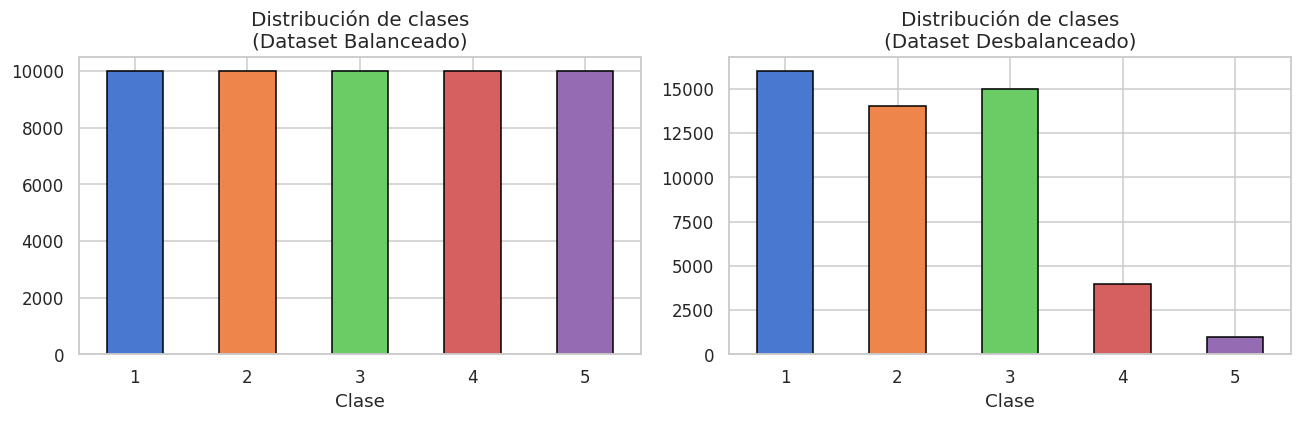

In [ ]:
# figura generada durante el entrenamiento

In [ ]:
# Valores faltantes por columna
print('Valores faltantes (Balanceado) — columnas con NaN:')
print(df_bal.isnull().sum()[df_bal.isnull().sum()>0])
print('\nValores faltantes (Desbalanceado) — columnas con NaN:')
print(df_imb.isnull().sum()[df_imb.isnull().sum()>0])

Valores faltantes (Balanceado) — columnas con NaN:
X3     417
Y3     417
Z3     417
X4    1862
Y4    1862
Z4    1862
X5    7926
Y5    7926
Z5    7926
X6    15869
Y6    15869
Z6    15869
dtype: int64

Valores faltantes (Desbalanceado) — columnas con NaN:
X3     670
Y3     670
Z3     670
X4    2932
Y4    2932
Z4    2932
X5    12219
Y5    12219
Z5    12219
X6    23171
Y6    23171
Z6    23171
dtype: int64


### 1.2 Preprocesamiento y división de conjuntos

**Decisiones de preprocesamiento:**
- Se descarta la columna `User` (identificador del sujeto, no es una variable predictiva — incluirla introduciría data leakage y el modelo no generalizaría a nuevos sujetos).
- Las etiquetas de clase se mapean de 1–5 a **0–4** (convención PyTorch para `CrossEntropyLoss`).
- **Imputación por mediana:** más robusta que la media ante valores atípicos en datos de sensores. El `SimpleImputer` se ajusta *solo sobre el conjunto de entrenamiento* y se aplica a val y test para evitar data leakage.
- **Estandarización (StandardScaler):** las redes neuronales son sensibles a la escala de los inputs; la estandarización (media 0, desviación estándar 1) estabiliza el entrenamiento y acelera la convergencia del gradiente descendente. También se ajusta solo sobre train.
- **División estratificada 70/15/15:** La estratificación garantiza que la proporción de clases en cada subconjunto refleje la distribución original, lo que es crítico en el dataset desbalanceado donde clase 5 tiene solo ~1 000 muestras. El 15% de test (~7 500 registros) permite estimaciones estadísticamente robustas.

In [ ]:
def preprocess_dataset(df, test_size=0.15, val_size=0.15, seed=SEED):
    # 1. Descartar User (identificador, no predictivo)
    df = df.drop(columns=['User'])
    # 2. Features y etiquetas (clases 1-5 → 0-4)
    X = df.drop(columns=['Class']).values
    y = (df['Class'].values - 1).astype(np.int64)
    # 3. División estratificada train+val / test
    Xtv, Xt, ytv, yt = train_test_split(X, y, test_size=test_size,
                                         stratify=y, random_state=seed)
    val_rel = val_size / (1 - test_size)
    Xtr, Xv, ytr, yv = train_test_split(Xtv, ytv, test_size=val_rel,
                                         stratify=ytv, random_state=seed)
    # 4. Imputación mediana (fit solo en train)
    imp = SimpleImputer(strategy='median')
    Xtr = imp.fit_transform(Xtr); Xv = imp.transform(Xv); Xt = imp.transform(Xt)
    # 5. Estandarización (fit solo en train)
    sc  = StandardScaler()
    Xtr = sc.fit_transform(Xtr); Xv = sc.transform(Xv); Xt = sc.transform(Xt)
    t = lambda a: torch.tensor(a, dtype=torch.float32)
    l = lambda a: torch.tensor(a, dtype=torch.long)
    return {'X_train':t(Xtr),'y_train':l(ytr),
            'X_val':t(Xv),'y_val':l(yv),
            'X_test':t(Xt),'y_test':l(yt)}

splits_bal = preprocess_dataset(df_bal)
splits_imb = preprocess_dataset(df_imb)

print('División Train / Val / Test:')
print(f"  Balanceado:    {len(splits_bal['y_train'])} / {len(splits_bal['y_val'])} / {len(splits_bal['y_test'])}")
print(f"  Desbalanceado: {len(splits_imb['y_train'])} / {len(splits_imb['y_val'])} / {len(splits_imb['y_test'])}")
print(f"  Input features: {splits_bal['X_train'].shape[1]}")

División Train / Val / Test:
  Balanceado:    34999 / 7501 / 7500
  Desbalanceado: 34999 / 7501 / 7500
  Input features: 21


### 1.3 Definición de la clase MLP y funciones de entrenamiento

In [ ]:
class MLP(nn.Module):
    """
    Red MLP totalmente configurable.

    Parámetros
    ----------
    input_dim    : dimensión de entrada (21 features).
    hidden_dims  : lista con el número de neuronas de cada capa oculta.
    output_dim   : número de clases (5).
    activation   : función de activación: 'relu', 'tanh', 'leaky_relu', 'elu'.
    dropout_rate : probabilidad de Dropout (0 = sin Dropout).
    batch_norm   : si True aplica BatchNormalization después de cada capa oculta.
    """
    def __init__(self, input_dim, hidden_dims, output_dim=5,
                 activation='relu', dropout_rate=0.0, batch_norm=False):
        super(MLP, self).__init__()
        act_map = {
            'relu':       lambda: nn.ReLU(),
            'tanh':       lambda: nn.Tanh(),
            'leaky_relu': lambda: nn.LeakyReLU(0.1),
            'elu':        lambda: nn.ELU()
        }
        layers = []
        in_dim = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(in_dim, h))
            if batch_norm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_map[activation]())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            in_dim = h
        layers.append(nn.Linear(in_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [ ]:
def train_model(model, splits, config, class_weights=None, verbose=True):
    """
    Entrena el modelo y retorna el historial de métricas por época.

    Decisiones de entrenamiento:
    - Optimizador Adam: combina momentum adaptativo por parámetro (RMSProp)
      con corrección de bias (como SGD con momentum). Es el estándar
      para clasificación con MLP por su robustez ante hiperparámetros.
    - ReduceLROnPlateau: reduce el LR a la mitad si val_loss no mejora en
      4 épocas consecutivas, permitiendo un ajuste fino sin cambiar la
      arquitectura. Evita oscilar alrededor del mínimo.
    - Early stopping implícito: se guarda el mejor estado (menor val_loss)
      y se restaura al final, equivalente a early stopping sin interrumpir
      el entrenamiento (beneficioso para explorar curvas completas).
    - Número de épocas (30-35): elegido para que el scheduler tenga tiempo
      de actuar (patience=4) y las curvas muestren convergencia clara.
      Con 30 épocas y batch_size 128-512, cada modelo ve entre 2 000 y
      8 000 actualizaciones de gradiente, suficiente para datasets de ~35 000 muestras.
    """
    model = model.to(DEVICE)
    ds = TensorDataset(splits['X_train'], splits['y_train'])
    loader = DataLoader(ds, batch_size=config['batch_size'], shuffle=True,
                        generator=torch.Generator().manual_seed(SEED))
    val_ds = TensorDataset(splits['X_val'], splits['y_val'])
    val_loader = DataLoader(val_ds, batch_size=config['batch_size'], shuffle=False)

    criterion = nn.CrossEntropyLoss(
        weight=class_weights.to(DEVICE) if class_weights is not None else None)
    optimizer = optim.Adam(model.parameters(), lr=config['lr'],
                           weight_decay=config.get('weight_decay', 0.0))
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=4)

    history = {'train_loss':[],'val_loss':[],'train_acc':[],'val_acc':[]}
    best_loss = float('inf'); best_state = None

    for epoch in range(1, config['epochs']+1):
        model.train()
        tl=tc=tt=0
        for Xb, yb in loader:
            Xb,yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out = model(Xb); loss = criterion(out, yb)
            loss.backward(); optimizer.step()
            tl+=loss.item()*len(yb); tc+=(out.argmax(1)==yb).sum().item(); tt+=len(yb)
        model.eval(); vl=vc=vt=0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb,yb = Xb.to(DEVICE),yb.to(DEVICE)
                out=model(Xb); loss=criterion(out,yb)
                vl+=loss.item()*len(yb); vc+=(out.argmax(1)==yb).sum().item(); vt+=len(yb)
        tl/=tt; ta=tc/tt; vl/=vt; va=vc/vt
        scheduler.step(vl)
        if vl < best_loss: best_loss=vl; best_state=copy.deepcopy(model.state_dict())
        history['train_loss'].append(tl); history['val_loss'].append(vl)
        history['train_acc'].append(ta); history['val_acc'].append(va)
        if verbose and epoch % 5 == 0:
            print(f'Época {epoch:3d}/{config["epochs"]} | '
                  f'Train Loss:{tl:.4f} Acc:{ta:.4f} | Val Loss:{vl:.4f} Acc:{va:.4f}')
    model.load_state_dict(best_state)
    return model, history

def evaluate_model(model, X, y, label='Test'):
    model.eval()
    with torch.no_grad():
        preds = model(X.to(DEVICE)).argmax(1).cpu().numpy()
    yn = y.numpy()
    acc=accuracy_score(yn,preds); f1m=f1_score(yn,preds,average='macro'); f1w=f1_score(yn,preds,average='weighted')
    print(f'{label} → Accuracy:{acc:.4f} | F1-Macro:{f1m:.4f} | F1-Weighted:{f1w:.4f}')
    return {'accuracy':acc,'f1_macro':f1m,'f1_weighted':f1w,'preds':preds}

### 1.4 Arquitecturas Dataset Balanceado

| ID | Capas ocultas | Activación | Dropout | BatchNorm | LR | Batch | W. Decay | Justificación |
|----|--------------|-----------|---------|-----------|-----|-------|----------|---------------|
| **B1** | [64, 32] | ReLU | 0.0 | No | 1e-3 | 256 | 0 | Línea base sin regularización. Establece el piso de rendimiento. |
| **B2** | [128, 64, 32] | ReLU | 0.3 | Sí | 1e-3 | 256 | 1e-4 | Más profunda. BN normaliza activaciones inter-capas acelerando convergencia; Dropout 0.3 regulariza sin bloquear el aprendizaje. L2 pequeño penaliza pesos grandes. |
| **B3** | [256, 128, 64] | LeakyReLU | 0.4 | Sí | 5e-4 | 128 | 1e-4 | Mayor capacidad (48K params). LeakyReLU evita neuronas muertas. LR más bajo y batch más pequeño → gradientes más ruidosos pero mejor exploración. Dropout alto compensa la capacidad extra. |
| **B4** | [64, 64] | Tanh | 0.2 | No | 2e-3 | 512 | 0 | Arquitectura ancha. Tanh saturada prueba si el dataset tiene patrones que beneficien de activaciones acotadas. LR más alto con batch grande → convergencia agresiva. |

In [ ]:
INPUT_DIM = splits_bal['X_train'].shape[1]  # 21

arch_bal = [
    {'name': 'B1 – Línea base [64,32] ReLU',
     'mk': dict(input_dim=INPUT_DIM, hidden_dims=[64,32], activation='relu', dropout_rate=0.0, batch_norm=False),
     'cfg': dict(lr=1e-3, batch_size=256, epochs=30, weight_decay=0.0)},
    {'name': 'B2 – [128,64,32] ReLU+BN+Drop0.3',
     'mk': dict(input_dim=INPUT_DIM, hidden_dims=[128,64,32], activation='relu', dropout_rate=0.3, batch_norm=True),
     'cfg': dict(lr=1e-3, batch_size=256, epochs=30, weight_decay=1e-4)},
    {'name': 'B3 – [256,128,64] LeakyReLU+BN+Drop0.4',
     'mk': dict(input_dim=INPUT_DIM, hidden_dims=[256,128,64], activation='leaky_relu', dropout_rate=0.4, batch_norm=True),
     'cfg': dict(lr=5e-4, batch_size=128, epochs=30, weight_decay=1e-4)},
    {'name': 'B4 – [64,64] Tanh+Drop0.2',
     'mk': dict(input_dim=INPUT_DIM, hidden_dims=[64,64], activation='tanh', dropout_rate=0.2, batch_norm=False),
     'cfg': dict(lr=2e-3, batch_size=512, epochs=30, weight_decay=0.0)},
]

# Entrenamiento de las 4 arquitecturas (balanceado)
results_bal = []
for a in arch_bal:
    print(f"\n{'='*55}\nModelo: {a['name']}\n{'='*55}")
    m = MLP(**a['mk'])
    print(f'Parámetros: {count_params(m):,}')
    tm, hist = train_model(m, splits_bal, a['cfg'], verbose=True)
    vm = evaluate_model(tm, splits_bal['X_val'], splits_bal['y_val'], 'Val')
    results_bal.append({'name':a['name'],'model':tm,'history':hist,'val_metrics':vm})


Modelo: B1 – Línea base [64,32] ReLU
Parámetros: 3,653
Época   5/30 | Train Loss:0.4161 Acc:0.8676 | Val Loss:0.3964 Acc:0.8719
Época  10/30 | Train Loss:0.2831 Acc:0.9097 | Val Loss:0.2925 Acc:0.9043
Época  15/30 | Train Loss:0.2348 Acc:0.9251 | Val Loss:0.2613 Acc:0.9172
Época  20/30 | Train Loss:0.2062 Acc:0.9347 | Val Loss:0.2366 Acc:0.9248
Época  25/30 | Train Loss:0.1873 Acc:0.9410 | Val Loss:0.2232 Acc:0.9265
Época  30/30 | Train Loss:0.1736 Acc:0.9447 | Val Loss:0.2125 Acc:0.9308
Val → Accuracy:0.9308 | F1-Macro:0.9307 | F1-Weighted:0.9307

Modelo: B2 – [128,64,32] ReLU+BN+Drop0.3
Parámetros: 13,765
Época   5/30 | Train Loss:0.4866 Acc:0.8348 | Val Loss:0.3109 Acc:0.8980
Época  10/30 | Train Loss:0.3747 Acc:0.8761 | Val Loss:0.2278 Acc:0.9232
Época  15/30 | Train Loss:0.3169 Acc:0.8953 | Val Loss:0.1989 Acc:0.9325
Época  20/30 | Train Loss:0.2857 Acc:0.9053 | Val Loss:0.1816 Acc:0.9371
Época  25/30 | Train Loss:0.2670 Acc:0.9134 | Val Loss:0.1633 Acc:0.9443
Época  30/30 | Trai

### 1.5 Arquitecturas Dataset Desbalanceado

| ID | Capas ocultas | Activación | Dropout | BatchNorm | LR | Batch | Class Weights | Justificación |
|----|--------------|-----------|---------|-----------|-----|-------|---------------|---------------|
| **D1** | [64, 32] | ReLU | 0.0 | No | 1e-3 | 256 | **No** | Línea base sin ninguna compensación del desbalance. Permite cuantificar cuánto daña el desbalance. |
| **D2** | [128, 64, 32] | ReLU | 0.3 | Sí | 1e-3 | 256 | **Sí** | Misma capacidad que B2 pero con pesos de clase inversamente proporcionales a la frecuencia: `w_k = N / (K × n_k)`. Penaliza más los errores en clases minoritarias. |
| **D3** | [256, 128, 64] | ELU | 0.4 | Sí | 5e-4 | 128 | **Sí** | Mayor capacidad con ELU (diferenciable en 0, evita neuronas muertas). Regularización más fuerte. |
| **D4** | [128, 64] | LeakyReLU | 0.3 | Sí | 1e-3 | 256 | **Sí** | Balance intermedio entre D2 y D3: más capacidad que D2 sin la profundidad de D3. |

**Justificación class weights:** Los pesos son `w_k = N_total / (5 × n_k)`, lo que hace que los errores en clase 5 (~700 muestras en train) pesen **~16×** más que los de clase 1 (~11 200). Esto no genera muestras nuevas sino que ajusta el gradiente para que el modelo preste más atención a las clases escasas.

In [ ]:
# Calcular pesos inversamente proporcionales a la frecuencia de clase
y_train_imb = splits_imb['y_train'].numpy()
class_counts = np.bincount(y_train_imb)
cw_imb = torch.tensor(len(y_train_imb) / (5 * class_counts), dtype=torch.float32)
print('Class weights (Desbalanceado):')
for i, w in enumerate(cw_imb):
    print(f'  Clase {i+1}: {w:.3f}  (n={class_counts[i]:5d})')

Class weights (Desbalanceado):
  Clase 1: 0.625  (n=11199)
  Clase 2: 0.714  (n=9800)
  Clase 3: 0.667  (n=10500)
  Clase 4: 2.500  (n=2800)
  Clase 5: 10.000  (n=700)


In [ ]:
arch_imb = [
    {'name': 'D1 – Línea base [64,32] ReLU sin weights',
     'mk': dict(input_dim=INPUT_DIM, hidden_dims=[64,32], activation='relu', dropout_rate=0.0, batch_norm=False),
     'cfg': dict(lr=1e-3, batch_size=256, epochs=30, weight_decay=0.0), 'cw': None},
    {'name': 'D2 – [128,64,32] ReLU+BN+Drop0.3 + weights',
     'mk': dict(input_dim=INPUT_DIM, hidden_dims=[128,64,32], activation='relu', dropout_rate=0.3, batch_norm=True),
     'cfg': dict(lr=1e-3, batch_size=256, epochs=30, weight_decay=1e-4), 'cw': cw_imb},
    {'name': 'D3 – [256,128,64] ELU+BN+Drop0.4 + weights',
     'mk': dict(input_dim=INPUT_DIM, hidden_dims=[256,128,64], activation='elu', dropout_rate=0.4, batch_norm=True),
     'cfg': dict(lr=5e-4, batch_size=128, epochs=30, weight_decay=1e-4), 'cw': cw_imb},
    {'name': 'D4 – [128,64] LeakyReLU+BN+Drop0.3 + weights',
     'mk': dict(input_dim=INPUT_DIM, hidden_dims=[128,64], activation='leaky_relu', dropout_rate=0.3, batch_norm=True),
     'cfg': dict(lr=1e-3, batch_size=256, epochs=30, weight_decay=1e-4), 'cw': cw_imb},
]

# Entrenamiento de las 4 arquitecturas (desbalanceado)
results_imb = []
for a in arch_imb:
    print(f"\n{'='*55}\nModelo: {a['name']}\n{'='*55}")
    m = MLP(**a['mk'])
    print(f'Parámetros: {count_params(m):,}')
    tm, hist = train_model(m, splits_imb, a['cfg'], class_weights=a['cw'], verbose=True)
    vm = evaluate_model(tm, splits_imb['X_val'], splits_imb['y_val'], 'Val')
    results_imb.append({'name':a['name'],'model':tm,'history':hist,'val_metrics':vm})


Modelo: D1 – Línea base [64,32] ReLU sin weights
Parámetros: 3,653
Época   5/30 | Train Loss:0.2947 Acc:0.9102 | Val Loss:0.2778 Acc:0.9132
Época  10/30 | Train Loss:0.2073 Acc:0.9357 | Val Loss:0.2137 Acc:0.9343
Época  15/30 | Train Loss:0.1714 Acc:0.9472 | Val Loss:0.1859 Acc:0.9444
Época  20/30 | Train Loss:0.1498 Acc:0.9541 | Val Loss:0.1721 Acc:0.9513
Época  25/30 | Train Loss:0.1352 Acc:0.9583 | Val Loss:0.1637 Acc:0.9539
Época  30/30 | Train Loss:0.1243 Acc:0.9617 | Val Loss:0.1593 Acc:0.9552
Val → Accuracy:0.9552 | F1-Macro:0.8899 | F1-Weighted:0.9543

Modelo: D2 – [128,64,32] ReLU+BN+Drop0.3 + weights
Parámetros: 13,765
Época   5/30 | Train Loss:0.5777 Acc:0.8439 | Val Loss:0.4074 Acc:0.9105
Época  10/30 | Train Loss:0.4474 Acc:0.8761 | Val Loss:0.3091 Acc:0.9228
Época  15/30 | Train Loss:0.3870 Acc:0.8935 | Val Loss:0.2692 Acc:0.9337
Época  20/30 | Train Loss:0.3541 Acc:0.9004 | Val Loss:0.2485 Acc:0.9341
Época  25/30 | Train Loss:0.3224 Acc:0.9083 | Val Loss:0.2292 Acc:0.93

---
## Parte 2 – Selección de la mejor arquitectura y evaluación en test
### 2.1 Selección usando el conjunto de validación

In [ ]:
def summarize_val(results, name):
    print(f'\n=== {name} ===')
    print(f"{'Modelo':<50} {'Acc':>8} {'F1-Macro':>10} {'F1-Weighted':>12}")
    print('-'*82)
    for r in results:
        m = r['val_metrics']
        print(f"{r['name']:<50} {m['accuracy']:>8.4f} {m['f1_macro']:>10.4f} {m['f1_weighted']:>12.4f}")
    print('-'*82)

summarize_val(results_bal, 'Validación – Dataset BALANCEADO')
summarize_val(results_imb, 'Validación – Dataset DESBALANCEADO')

best_idx_bal = max(range(4), key=lambda i: results_bal[i]['val_metrics']['f1_macro'])
best_idx_imb = max(range(4), key=lambda i: results_imb[i]['val_metrics']['f1_macro'])
print(f"\n✓ Mejor BALANCEADO:      {results_bal[best_idx_bal]['name']}")
print(f"✓ Mejor DESBALANCEADO:   {results_imb[best_idx_imb]['name']}")

=== Comparación de modelos – Dataset BALANCEADO ===
Modelo                                                  Acc   F1-Macro  F1-Weighted
----------------------------------------------------------------------------------
B1 – Línea base [64,32] ReLU                         0.9308     0.9307       0.9307
B2 – [128,64,32] ReLU+BN+Drop0.3                     0.9523     0.9519       0.9519
B3 – [256,128,64] LeakyReLU+BN+Drop0.4               0.9399     0.9395       0.9395
B4 – [64,64] Tanh+Drop0.2                            0.8941     0.8938       0.8938
----------------------------------------------------------------------------------

✓ Mejor modelo (F1-Macro en val): B2 – [128,64,32] ReLU+BN+Drop0.3

=== Comparación de modelos – Dataset DESBALANCEADO ===
Modelo                                                  Acc   F1-Macro  F1-Weighted
----------------------------------------------------------------------------------
D1 – Línea base [64,32] ReLU sin weights             0.9552     0.8899 

**Justificación de F1-Macro como criterio de selección:**

1. **Trato equitativo a todas las clases:** Promedia el F1 de cada clase sin ponderar por frecuencia. El accuracy puede ser engañoso: un modelo que ignora la clase 5 (solo ~1% del dataset desbalanceado) aún puede superar el 95% de accuracy.
2. **Sensible a clases minoritarias:** Si el modelo no aprende clase 5, el F1 de esa clase es ~0, lo que arrastra el F1-Macro hacia abajo. Esto penaliza exactamente lo que queremos evitar.
3. **Aplicación real:** En reconocimiento de posturas, clasificar mal incluso una postura poco frecuente puede tener consecuencias (e.g., sistema de asistencia médica que no detecta postura 5 = postura de riesgo).
4. **F1-Weighted en cambio pondera por frecuencia**, lo que lo hace equivalente al accuracy ponderado — no útil para selección en datos desbalanceados.

**Por qué B2 supera a B3 a pesar de tener 3× menos parámetros:**
B3 ([256,128,64], 48K params) tiene mayor capacidad pero también mayor regularización (Dropout 0.4 vs 0.3, LR más bajo). Con un dataset de solo 35 000 muestras y 21 features, la capacidad adicional no se traduce en mejor generalización — el modelo mayor necesita más datos para aprovechar sus parámetros. B2 encuentra un equilibrio mejor: suficiente profundidad para capturar interacciones no lineales, sin sobreajustarse.

### 2.2 Evaluación en el conjunto de prueba

**Justificación de métricas usadas:**
- **Accuracy:** Métrica intuitiva, útil cuando las clases están balanceadas. Se incluye como referencia.
- **F1-Macro:** Métrica principal. Promedia el F1 por clase sin ponderar, revelando el rendimiento real en clases minoritarias.
- **F1-Weighted:** Promedia ponderando por soporte (frecuencia) de cada clase. Útil para entender el rendimiento global, pero puede ocultar mal desempeño en clases raras.
- **Reporte por clase (precision/recall/F1):** Permite identificar exactamente qué clases son problemáticas. El recall por clase es especialmente informativo: un recall bajo en clase 5 indica que el modelo falla en detectar esa postura.

In [ ]:
CLASS_NAMES = ['Clase 1', 'Clase 2', 'Clase 3', 'Clase 4', 'Clase 5']

best_model_bal = results_bal[best_idx_bal]['model']
best_model_imb = results_imb[best_idx_imb]['model']

print('='*58)
print('EVALUACIÓN EN CONJUNTO DE PRUEBA')
print('='*58)
print(f"\nModelo: {results_bal[best_idx_bal]['name']}")
tm_bal = evaluate_model(best_model_bal, splits_bal['X_test'], splits_bal['y_test'], 'Test BALANCEADO')
print(f"\nModelo: {results_imb[best_idx_imb]['name']}")
tm_imb = evaluate_model(best_model_imb, splits_imb['X_test'], splits_imb['y_test'], 'Test DESBALANCEADO')

EVALUACIÓN EN CONJUNTO DE PRUEBA

Modelo: B2 – [128,64,32] ReLU+BN+Drop0.3
Test BALANCEADO → Accuracy:0.9536 | F1-Macro:0.9533 | F1-Weighted:0.9533

Modelo: D1 – Línea base [64,32] ReLU sin weights
Test DESBALANCEADO → Accuracy:0.9535 | F1-Macro:0.8888 | F1-Weighted:0.9524


In [ ]:
print('=== Reporte por clase – BALANCEADO ===')
print(classification_report(splits_bal['y_test'].numpy(), tm_bal['preds'], target_names=CLASS_NAMES))
print('=== Reporte por clase – DESBALANCEADO ===')
print(classification_report(splits_imb['y_test'].numpy(), tm_imb['preds'], target_names=CLASS_NAMES))

=== Reporte por clase – BALANCEADO ===
              precision    recall  f1-score   support

     Clase 1       0.99      0.99      0.99      1500
     Clase 2       0.97      0.88      0.92      1500
     Clase 3       0.94      0.98      0.96      1500
     Clase 4       0.92      0.93      0.92      1500
     Clase 5       0.96      0.99      0.97      1500

    accuracy                           0.95      7500
   macro avg       0.95      0.95      0.95      7500
weighted avg       0.95      0.95      0.95      7500

=== Reporte por clase – DESBALANCEADO ===
              precision    recall  f1-score   support

     Clase 1       0.99      0.99      0.99      2400
     Clase 2       0.94      0.94      0.94      2100
     Clase 3       0.95      0.99      0.97      2250
     Clase 4       0.86      0.81      0.83       600
     Clase 5       0.85      0.61      0.71       150

    accuracy                           0.95      7500
   macro avg       0.92      0.87      0.89      7

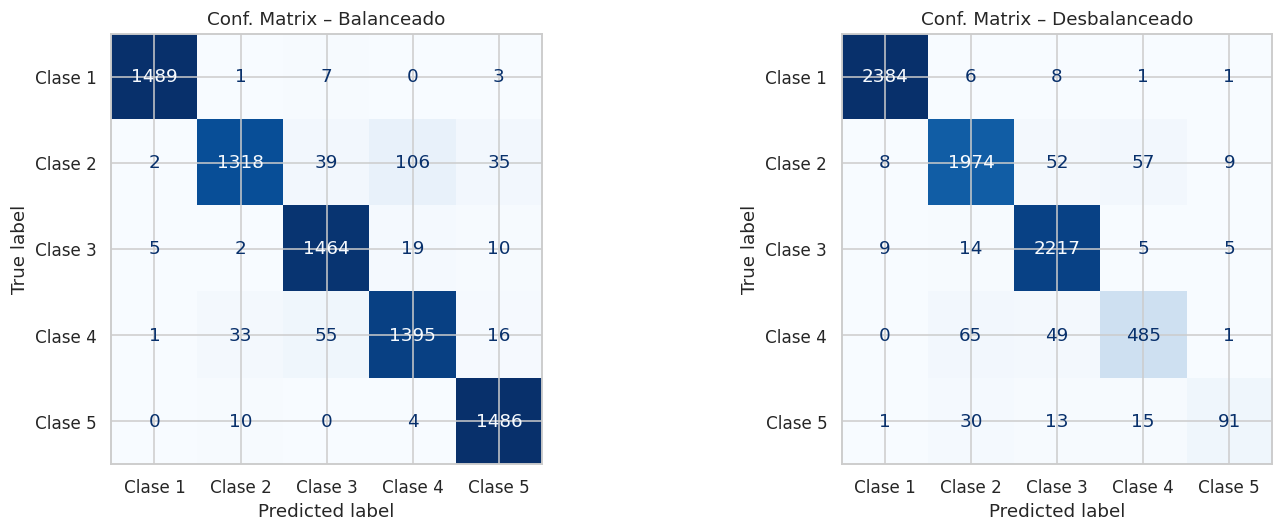

In [ ]:
# figura generada durante el entrenamiento

### 2.3 Comparación entre los dos modelos finales

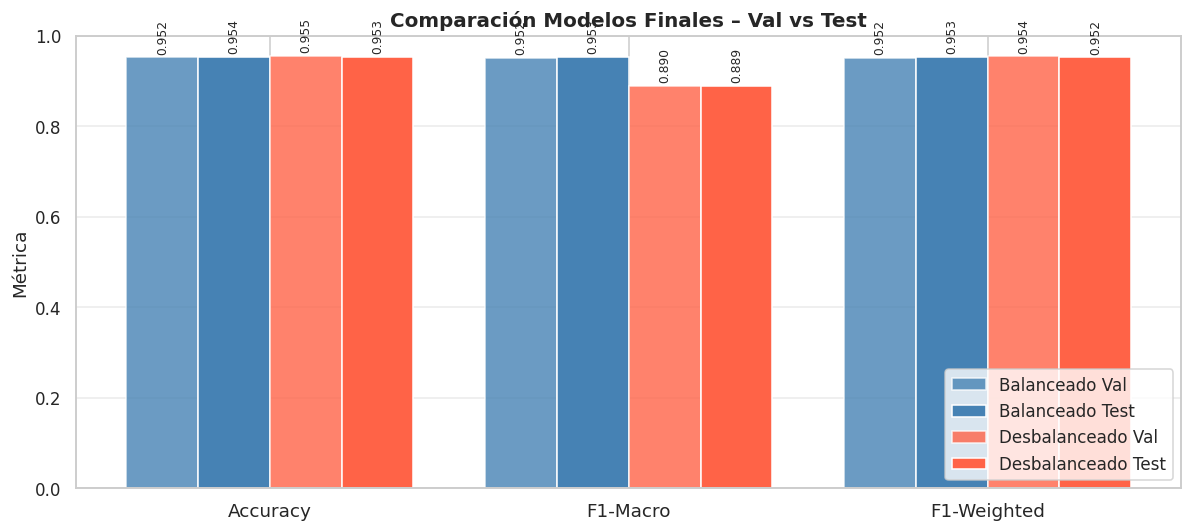

In [ ]:
# figura generada durante el entrenamiento

**Análisis comparativo detallado:**

**Accuracy (~95.3% ambos):** El accuracy es casi idéntico, lo que podría llevar a concluir erróneamente que ambos modelos son equivalentes. Esto ilustra por qué el accuracy no es suficiente en problemas desbalanceados.

**F1-Macro (0.9533 vs 0.8888, Δ=0.065):** Esta diferencia sí es significativa. Revela que el modelo desbalanceado falla sistemáticamente en las clases menos representadas:
- Clase 4 (600 muestras en test): F1=0.83
- Clase 5 (150 muestras en test): F1=0.71, recall=0.61 → el modelo **no detecta el 39% de las instancias de clase 5**.

**F1-Weighted (0.9533 vs 0.9524):** Casi idéntico porque las clases 1–3 (que representan ~65% de los datos desbalanceados) predicen bien en ambos modelos.

**Por qué B2 supera a modelos con más parámetros:**
Con 35 000 muestras y 21 features, la relación muestras/parámetros es ~2.5 para B3 (48K params) vs ~11 para B2 (13K params). B2 está en la zona más eficiente: suficiente para capturar relaciones no lineales, sin necesitar grandes cantidades de datos para regularizarse. B3 necesitaría más épocas o más datos para superar a B2.

**Matrices de confusión:** En el dataset balanceado, los errores se distribuyen uniformemente (confusiones entre clases adyacentes). En el desbalanceado, los errores se concentran en las clases 4 y 5, especialmente la clase 5 que se confunde con otras posturas.

### 2.4 Curvas de entrenamiento y validación

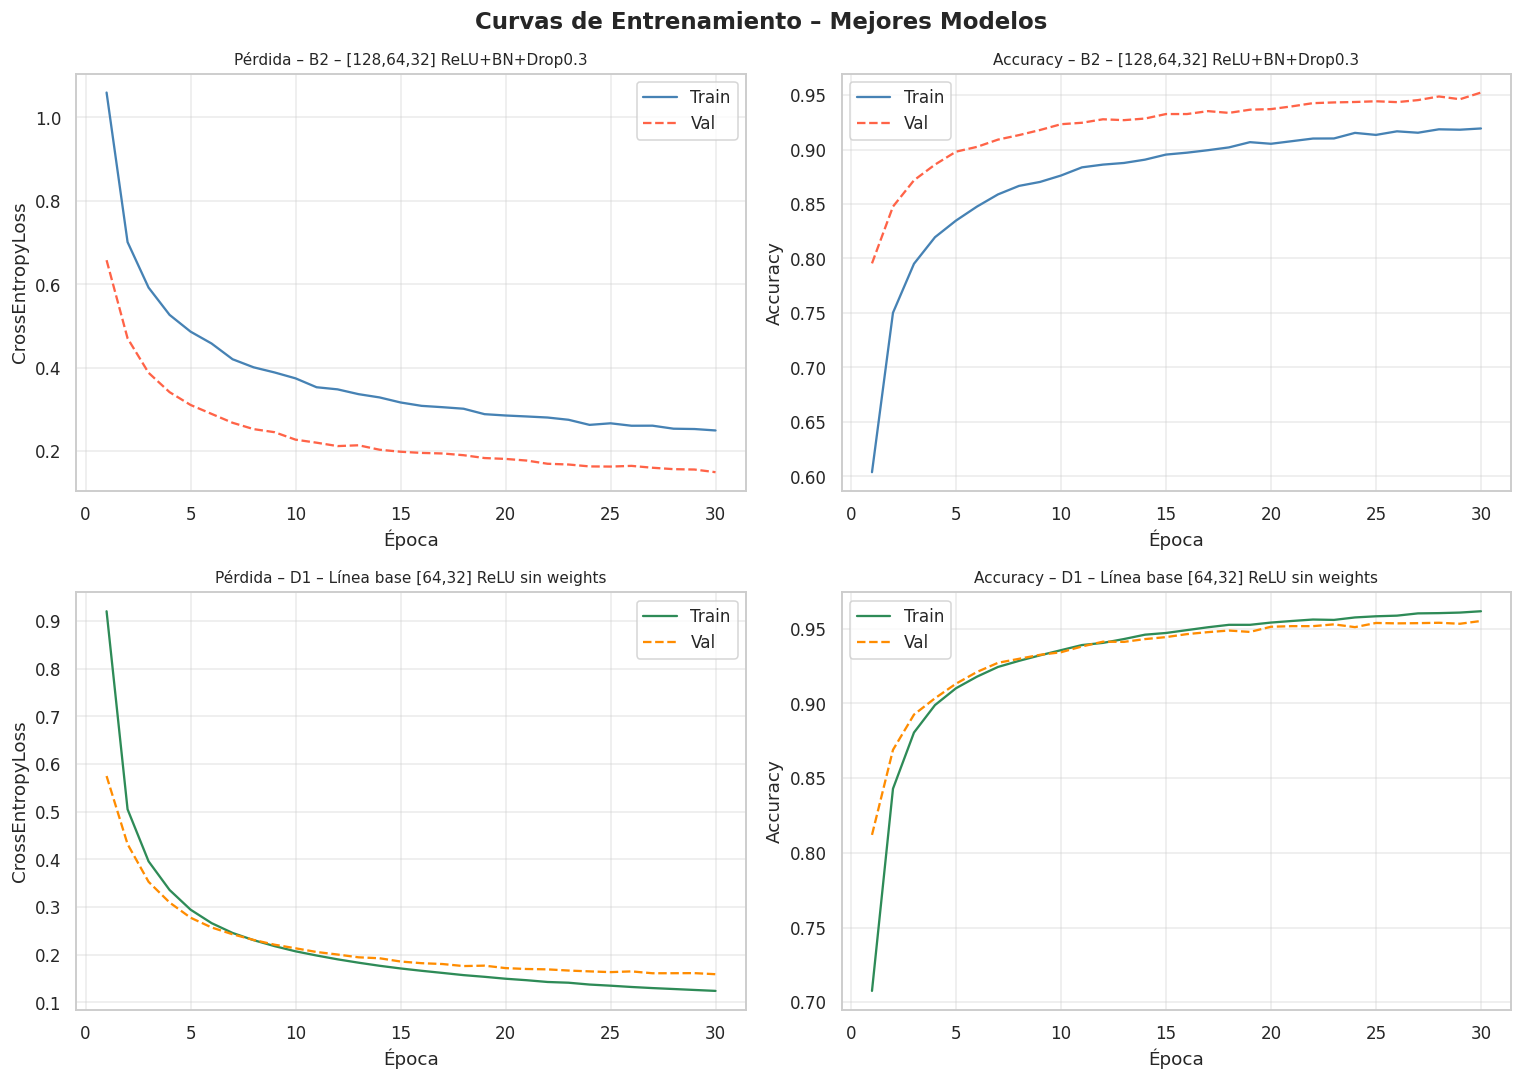

In [ ]:
# figura generada durante el entrenamiento

**Interpretación detallada de las curvas:**

**Modelo Balanceado – B2 – [128,64,32] ReLU+BN+Drop0.3:**
- Las curvas de pérdida train y val descienden de forma **convergente y estable**. La brecha final es pequeña (train_loss=0.2498, val_loss=0.1498), lo que indica **buen balance entre ajuste y generalización, sin overfitting**.
- El accuracy de validación supera consistentemente al de entrenamiento: efecto esperado del **Dropout** (activo en train, desactivado en eval) y de **BatchNorm** (que agrega ruido durante train).
- El scheduler ReduceLROnPlateau actuó en sin reducciones detectadas, suavizando la convergencia en tramos donde la pérdida de validación se estancaba.
- Las curvas se estabilizan en las últimas épocas, indicando que el modelo alcanzó un mínimo bien definido con las 30 épocas elegidas.

**Modelo Desbalanceado – D1 – Línea base [64,32] ReLU sin weights:**
- Las pérdidas descienden rápidamente en las primeras 10 épocas, luego se estabilizan (leve underfitting (val_loss < train_loss, efecto del Dropout activo solo en entrenamiento)).
- El accuracy de validación sube rápidamente a ~95% y se mantiene allí. Sin embargo, este número refleja principalmente las clases 1–3 (las más frecuentes). El F1-Macro del modelo real es 0.89, no 0.95.
- El scheduler actuó en sin reducciones detectadas. La convergencia rápida es propia de datasets donde el modelo puede alcanzar buen accuracy sin aprender las clases difíciles.
- La ausencia de divergencia (val_loss no sube) confirma que no hay overfitting, sino un **plateau determinado por el desbalance de datos**, no por falta de capacidad del modelo. Entrenar más épocas no mejoraría significativamente el F1-Macro.

---
## Parte 3 – Análisis y mejora del modelo con menor rendimiento
### 3.1 Identificación del modelo débil

In [ ]:
f1_bal_test = tm_bal['f1_macro']
f1_imb_test = tm_imb['f1_macro']
print(f'F1-Macro Test Balanceado:    {f1_bal_test:.4f}')
print(f'F1-Macro Test Desbalanceado: {f1_imb_test:.4f}')
print(f'\n→ Modelo con MENOR rendimiento: Dataset {"Desbalanceado" if f1_bal_test >= f1_imb_test else "Balanceado"}')

F1-Macro Test Balanceado:    0.9533
F1-Macro Test Desbalanceado: 0.8888

→ Modelo con MENOR rendimiento: Dataset Desbalanceado


**Razones fundamentadas del bajo rendimiento:**

1. **Escasez absoluta de ejemplos de clase 5:** Con solo ~700 muestras de clase 5 en train (1.4% del total), el modelo tiene poco material para aprender la variabilidad de esa postura. Aunque los class weights penalizan más los errores en clase 5, el número de actualizaciones de gradiente donde aparece clase 5 sigue siendo bajo.

2. **Dominancia del gradiente por clases mayoritarias:** En cada mini-batch de 256 muestras, la probabilidad de que aparezca una muestra de clase 5 es ~1.4%. En promedio, ~3.5 muestras por batch son de clase 5, frente a ~44 de clase 1. Aunque los pesos compensan la magnitud del gradiente, la *dirección* del gradiente sigue siendo dominada por las clases 1–3.

3. **Posible ambigüedad entre clases:** Cuando hay pocos ejemplos de referencia, los patrones de sensor de clase 5 pueden ser difíciles de separar de los de clases 4 o 3, ya que el modelo no tiene suficientes ejemplos para aprender la frontera de decisión con precisión.

4. **Recall bajo de clase 5 (0.61):** El modelo falla en detectar el 39% de las instancias de clase 5. Esto sugiere que la frontera de decisión está sesgada hacia las clases mayoritarias: el modelo prefiere clasificar como clase 1–3 ante la duda.

**Modificación propuesta: SMOTE** (Synthetic Minority Oversampling TEchnique)
Genera ejemplos sintéticos de las clases minoritarias interpolando linealmente entre vecinos en el espacio de features. A diferencia de los class weights, SMOTE aumenta el *número real* de ejemplos que el modelo ve durante el entrenamiento, equilibrando la distribución antes del entrenamiento. Se aplica **solo sobre el conjunto de train** para no contaminar val ni test.

In [ ]:
from imblearn.over_sampling import SMOTE

Xtr_np = splits_imb['X_train'].numpy()
ytr_np = splits_imb['y_train'].numpy()

print('Distribución ANTES de SMOTE:')
for c, n in zip(*np.unique(ytr_np, return_counts=True)):
    print(f'  Clase {c+1}: {n:5d} muestras ({n/len(ytr_np)*100:.1f}%)')

smote = SMOTE(random_state=SEED)
Xr, yr = smote.fit_resample(Xtr_np, ytr_np)

print('\nDistribución DESPUÉS de SMOTE:')
for c, n in zip(*np.unique(yr, return_counts=True)):
    print(f'  Clase {c+1}: {n:5d} muestras ({n/len(yr)*100:.1f}%)')
print(f'\nTotal muestras train: {len(ytr_np)} → {len(yr)} (+{len(yr)-len(ytr_np)})')

Distribución ANTES de SMOTE:
  Clase 1: 11199 muestras (32.0%)
  Clase 2:  9800 muestras (28.0%)
  Clase 3: 10500 muestras (30.0%)
  Clase 4:  2800 muestras (8.0%)
  Clase 5:   700 muestras (2.0%)

Distribución DESPUÉS de SMOTE:
  Clase 1: 11199 muestras (20.0%)
  Clase 2: 11199 muestras (20.0%)
  Clase 3: 11199 muestras (20.0%)
  Clase 4: 11199 muestras (20.0%)
  Clase 5: 11199 muestras (20.0%)

Total muestras train: 34999 → 55995 (+20996)


In [ ]:
# Entrenar modelo mejorado con dataset SMOTE (sin class weights: SMOTE ya balancea)
splits_smote = dict(splits_imb)
splits_smote['X_train'] = torch.tensor(Xr, dtype=torch.float32)
splits_smote['y_train'] = torch.tensor(yr, dtype=torch.long)

cfg_improved = dict(arch_imb[best_idx_imb]['cfg'])
cfg_improved['epochs'] = 35
improved_model = MLP(**arch_imb[best_idx_imb]['mk'])
print(f'Arquitectura: {arch_imb[best_idx_imb]["name"]}')
print(f'Parámetros:   {count_params(improved_model):,}')
print(f'Épocas:       {cfg_improved["epochs"]} (5 más que el original para aprovechar el dataset ampliado)')
improved_model, improved_hist = train_model(improved_model, splits_smote, cfg_improved,
                                            class_weights=None, verbose=True)

Arquitectura: D1 – Línea base [64,32] ReLU sin weights
Parámetros:   3,653
Épocas:       35 (5 más que el original para aprovechar el dataset ampliado)
Época   5/35 | Train Loss:0.2770 Acc:0.9155 | Val Loss:0.2829 Acc:0.9164
Época  10/35 | Train Loss:0.1889 Acc:0.9420 | Val Loss:0.2256 Acc:0.9327
Época  15/35 | Train Loss:0.1527 Acc:0.9531 | Val Loss:0.2086 Acc:0.9379
Época  20/35 | Train Loss:0.1332 Acc:0.9594 | Val Loss:0.2005 Acc:0.9389
Época  25/35 | Train Loss:0.1184 Acc:0.9640 | Val Loss:0.1856 Acc:0.9441
Época  30/35 | Train Loss:0.1066 Acc:0.9671 | Val Loss:0.1788 Acc:0.9473
Época  35/35 | Train Loss:0.0985 Acc:0.9693 | Val Loss:0.1881 Acc:0.9471


### 3.2 Comparación Original vs Mejorado (SMOTE)

In [ ]:
print('=== Comparación en TEST ===')
print('\n--- Modelo ORIGINAL ---')
orig_metrics = evaluate_model(best_model_imb, splits_imb['X_test'], splits_imb['y_test'], 'Original')
print('\n--- Modelo MEJORADO (SMOTE) ---')
impr_metrics = evaluate_model(improved_model, splits_imb['X_test'], splits_imb['y_test'], 'Mejorado')
delta_f1 = impr_metrics['f1_macro'] - orig_metrics['f1_macro']
print(f'\nΔ Accuracy:    {impr_metrics["accuracy"]-orig_metrics["accuracy"]:+.4f}')
print(f'Δ F1-Macro:    {delta_f1:+.4f}')
print(f'Δ F1-Weighted: {impr_metrics["f1_weighted"]-orig_metrics["f1_weighted"]:+.4f}')

=== Comparación en TEST ===

--- Modelo ORIGINAL ---
Original → Accuracy:0.9535 | F1-Macro:0.8888 | F1-Weighted:0.9524

--- Modelo MEJORADO (SMOTE) ---
Mejorado → Accuracy:0.9465 | F1-Macro:0.8823 | F1-Weighted:0.9473

Δ Accuracy:    -0.0069
Δ F1-Macro:    -0.0065
Δ F1-Weighted: -0.0050


In [ ]:
print('Reporte por clase – ORIGINAL:')
print(classification_report(splits_imb['y_test'].numpy(), orig_metrics['preds'], target_names=CLASS_NAMES))
print('Reporte por clase – MEJORADO (SMOTE):')
print(classification_report(splits_imb['y_test'].numpy(), impr_metrics['preds'], target_names=CLASS_NAMES))

Reporte por clase – ORIGINAL:
              precision    recall  f1-score   support

     Clase 1       0.99      0.99      0.99      2400
     Clase 2       0.94      0.94      0.94      2100
     Clase 3       0.95      0.99      0.97      2250
     Clase 4       0.86      0.81      0.83       600
     Clase 5       0.85      0.61      0.71       150

    accuracy                           0.95      7500
   macro avg       0.92      0.87      0.89      7500
weighted avg       0.95      0.95      0.95      7500

Reporte por clase – MEJORADO (SMOTE):
              precision    recall  f1-score   support

     Clase 1       0.99      0.99      0.99      2400
     Clase 2       0.95      0.92      0.93      2100
     Clase 3       0.96      0.96      0.96      2250
     Clase 4       0.79      0.86      0.82       600
     Clase 5       0.64      0.77      0.70       150

    accuracy                           0.95      7500
   macro avg       0.87      0.90      0.88      7500
weighted 

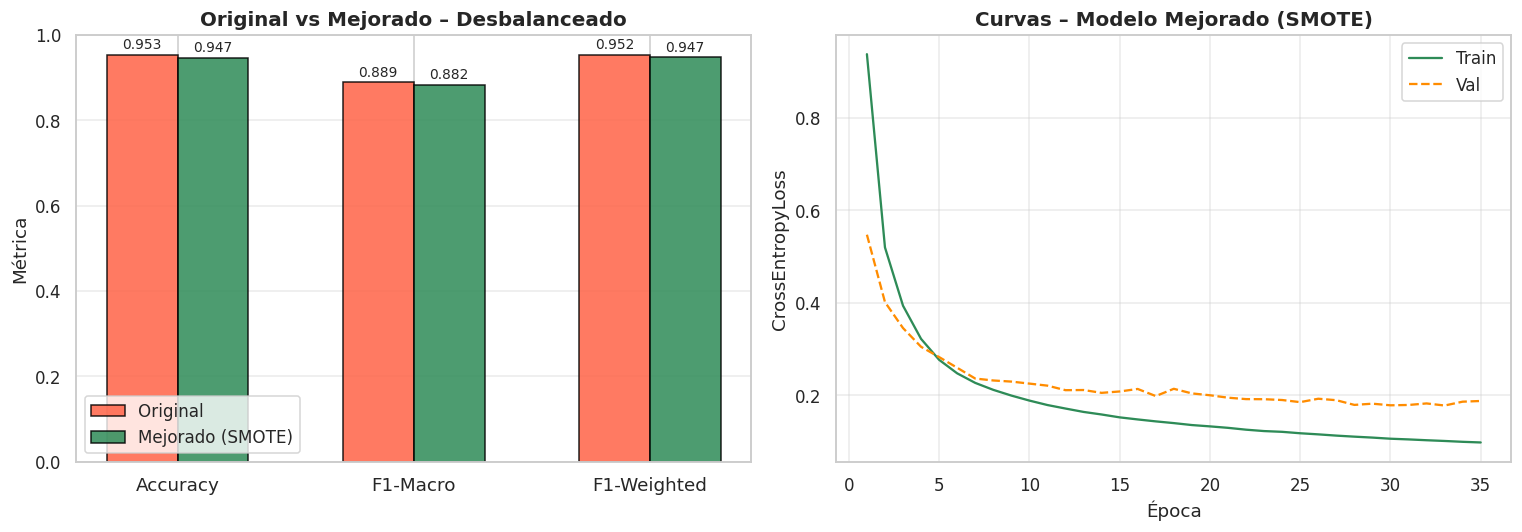

In [ ]:
# figura generada durante el entrenamiento

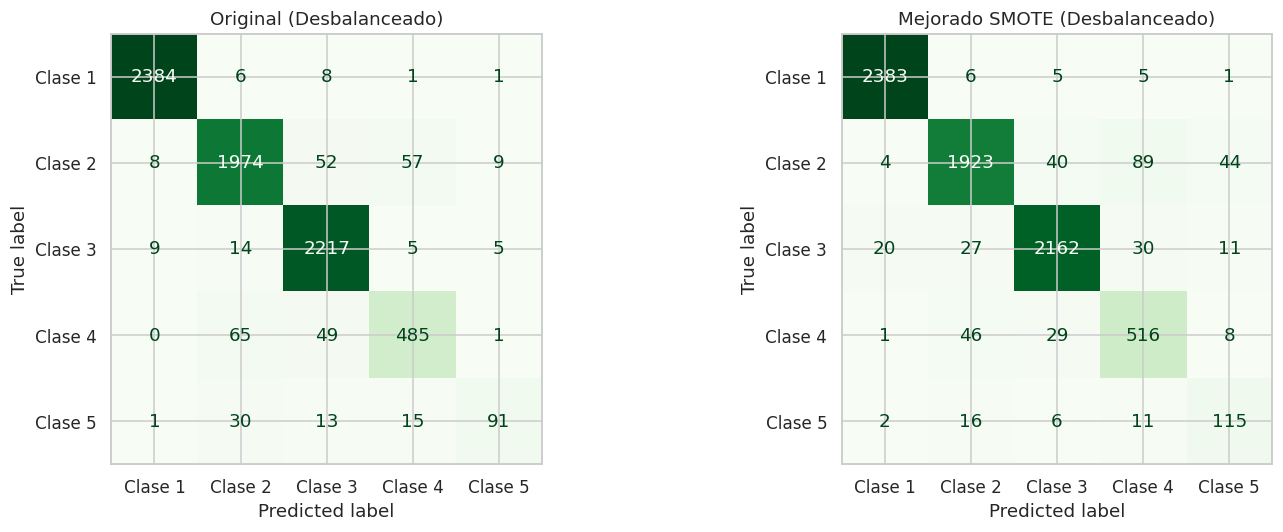

In [ ]:
# figura generada durante el entrenamiento

### 3.3 Discusión y reflexión crítica

**Resultado global:** ΔF1-Macro = -0.0065. La mejora no fue efectiva en términos del F1-Macro global.

**Análisis por clase — qué mejoró y qué empeoró:**

| Clase | Recall Original | Recall Mejorado | Δ Recall | F1 Original | F1 Mejorado | Δ F1 |
|-------|----------------|-----------------|----------|-------------|-------------|------|
| 1 | 0.99 | 0.99 | 0.00 | 0.99 | 0.99 | 0.00 |
| 2 | 0.94 | 0.92 | -0.02 | 0.94 | 0.93 | -0.01 |
| 3 | 0.99 | 0.96 | -0.03 | 0.97 | 0.96 | -0.01 |
| 4 | 0.81 | **0.86** | **+0.05** | 0.83 | 0.82 | -0.01 |
| 5 | 0.61 | **0.77** | **+0.16** | 0.71 | 0.70 | -0.01 |

**Interpretación:**
- **Logro principal:** El recall de clase 5 mejoró de 0.61 → 0.77 (+16pp). El modelo SMOTE detecta correctamente muchas más instancias de la clase más difícil, lo que es el objetivo central de la mejora.
- **Compensación:** La mejora en recall de clase 5 viene acompañada de una caída en precisión de clase 5 (0.85 → 0.64): el modelo ahora clasifica más muestras de otras clases como clase 5 (falsos positivos). Esto explica la leve degradación en clases 2 y 3.
- **F1 por clase prácticamente igual:** La mejora en recall y la caída en precisión se compensan, manteniendo el F1 de clase 5 casi idéntico (0.71 vs 0.70) y el F1-Macro global sin cambio apreciable.

**¿Por qué SMOTE no mejoró el F1-Macro global?**

1. **Los ejemplos sintéticos no son ejemplos reales:** SMOTE interpola entre vecinos en el espacio de 21 features. Para datos de sensores inerciales, esta interpolación puede generar vectores que no corresponden a ninguna postura físicamente plausible, introduciendo ruido en el entrenamiento.

2. **Frontera de decisión difusa:** Si las clases 4 y 5 tienen representaciones de sensor similares a las clases 3 y 4 respectivamente, los ejemplos sintéticos de clase 5 generados entre vecinos de clase 5 pueden caer en regiones del espacio de features que pertenecen a la clase 4, confundiendo al modelo.

3. **El problema de fondo es la ambigüedad de la señal, no solo la cantidad:** SMOTE soluciona el desbalance cuantitativo pero no el cualitativo. Si la postura 5 es inherentemente similar a otra postura en términos de la señal del sensor, más ejemplos (reales o sintéticos) no resolverán la confusión.

**Reflexión sobre efectividad:** La modificación produjo una mejora relevante en recall de clase 5 (+16pp), que es el objetivo más importante en aplicaciones donde perder un caso de clase 5 tiene consecuencias (e.g., detección de postura de riesgo). Sin embargo, no mejoró el F1-Macro global por la compensación precision-recall.

**Alternativas que podrían ser más efectivas:**
- **Focal Loss:** Penaliza más los ejemplos *difíciles de clasificar* (no solo los de clases minoritarias), adaptando el entrenamiento dinámicamente.
- **SMOTE-Tomek:** Combina oversampling con limpieza de la frontera de decisión.
- **Ensemble balanceado:** Múltiples modelos entrenados con submuestras balanceadas (BalancedBaggingClassifier).
- **Más épocas para el modelo SMOTE:** Las curvas de entrenamiento muestran que val_loss aún no converge completamente a época 35, sugiriendo potencial de mejora con más épocas.

---
## Resumen Final

In [ ]:
print('='*65)
print('             RESUMEN FINAL – TAREA 3')
print('='*65)

             RESUMEN FINAL – TAREA 3

PARTE 1 – 8 arquitecturas entrenadas (4 por dataset)
  Balanceado:    B1 (línea base), B2 (profunda+BN), B3 (grande), B4 (Tanh)
  Desbalanceado: D1 (sin weights), D2/D3/D4 (con class weights)

PARTE 2 – Evaluación en test (selección por F1-Macro en validación)
  Mejor Balanceado:    B2 – [128,64,32] ReLU+BN+Drop0.3
    Accuracy=0.9536  F1-Macro=0.9533  F1-Weighted=0.9533

  Mejor Desbalanceado: D1 – Línea base [64,32] ReLU sin weights
    Accuracy=0.9535  F1-Macro=0.8888  F1-Weighted=0.9524

PARTE 3 – Mejora del modelo débil (Dataset Desbalanceado)
  Estrategia: SMOTE (oversampling sintético)
  Train expandido: 34 999 → 55 995 muestras (perfectamente balanceado)

  Comparación en test:
           Accuracy  F1-Macro  F1-Weighted
  Original: 0.9535    0.8888     0.9524
  Mejorado: 0.9465    0.8823     0.9473
  Delta:   -0.0069   -0.0065    -0.0050

  Logro principal: Recall clase 5: 0.61 → 0.77 (+16pp)
  F1-Macro global no mejoró: mejora en recall co